# Assignment 2 — Georgian Spellcheck
## `data_and_training.ipynb` (v3)

**Architecture:** Bidirectional GRU Encoder → Bahdanau Attention → GRU Decoder

### What was wrong in v2 and what is fixed here

| # | Problem in v2 | Fix in v3 |
|---|---|---|
| 1 | Model instantiated with old `embed=64, hidden=256` — hyperparams defined later in training cell were never used | All hyperparams defined **once at the top**, model built from them |
| 2 | `OneCycleLR` stuck at `1.2e-5` all 30 epochs — `div_factor` defaulted to 25, scheduler barely moved | Replaced with `CosineAnnealingLR` — simple, predictable, verified to actually move |
| 3 | Scheduled sampling had no visible effect — loss curve had no inflection at epoch 10 | SS re-implemented and verified; prints SS prob each epoch |
| 4 | Dataset still contained multi-edit garbage pairs (3–4 edits, unlearnable) | Filtered inline: any pair with edit distance > 2 is dropped before training |

In [18]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
print("ready")

ready


In [19]:
import json, math, os, random, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 0 — Hyperparameters  *(all in one place — never split across cells again)*

In [20]:
# ── Architecture ──────────────────────────────────────────────────────────
EMBED_DIM   = 128
HIDDEN_DIM  = 256
ENC_LAYERS  = 2
DROPOUT     = 0.30

# ── Sequence lengths ───────────────────────────────────────────────────────
MAX_LEN     = 25   # covers max observed 22 (input) / 20 (target) + buffer

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE  = 512
N_EPOCHS    = 40
LR          = 3e-4   # confirmed safe for this architecture
LR_MIN      = 1e-5   # CosineAnnealingLR floor
GRAD_CLIP   = 1.0
PATIENCE    = 7      # early stopping patience

# ── Scheduled sampling ─────────────────────────────────────────────────────
SS_START_EPOCH = 10   # pure teacher forcing for first 10 epochs
SS_RAMP_EPOCHS = 15   # linearly ramp over next 15 epochs
SS_MAX_PROB    = 0.25 # cap at 25 %

# ── Data filtering ─────────────────────────────────────────────────────────
MAX_EDIT_DIST  = 2    # drop pairs with edit distance > this

# ── Misc ───────────────────────────────────────────────────────────────────
NUM_WORKERS = 2
SAVE_PATH   = Path("georgian_spellcheck_model.pt")

print("Hyperparameters:")
print(f"  embed={EMBED_DIM}  hidden={HIDDEN_DIM}  layers={ENC_LAYERS}  dropout={DROPOUT}")
print(f"  lr={LR}  epochs={N_EPOCHS}  patience={PATIENCE}  batch={BATCH_SIZE}")
print(f"  SS kicks in at epoch {SS_START_EPOCH}, ramps to {SS_MAX_PROB} over {SS_RAMP_EPOCHS} epochs")
print(f"  Max edit distance filter: {MAX_EDIT_DIST}")

Hyperparameters:
  embed=128  hidden=256  layers=2  dropout=0.3
  lr=0.0003  epochs=40  patience=7  batch=512
  SS kicks in at epoch 10, ramps to 0.25 over 15 epochs
  Max edit distance filter: 2


## 1 — Data Collection

In [21]:
dataset_dir = Path(
    kagglehub.dataset_download("giorgicheishvili/georgian-spellchecker-dataset")
)
print(f"Downloaded to : {dataset_dir}")
print("Files         :", [f.name for f in sorted(dataset_dir.iterdir())])

Downloaded to : /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset
Files         : ['char_vocab.json', 'georgian_spellcheck_dataset.csv', 'georgian_vocabulary.txt']


In [22]:
csv_path   = dataset_dir / "georgian_spellcheck_dataset.csv"
vocab_path = dataset_dir / "char_vocab.json"

df_raw = pd.read_csv(csv_path, encoding="utf-8")
with open(vocab_path, encoding="utf-8") as f:
    char_vocab = json.load(f)

print(f"Raw pairs loaded : {len(df_raw):,}")
print(f"Vocab size       : {char_vocab['vocab_size']}")

Raw pairs loaded : 1,461,168
Vocab size       : 43


## 2 — Data Generation & Cleaning

Five error types were used (keyboard swap 35 %, transposition 25 %, omission 20 %,
phonetic confusion 12 %, insertion 8 %).

**Fix applied here:** The uploaded dataset still contains multi-edit corruptions
(pairs like `პრივილეგიებჯსგწნ → პრივილეგიებისგან` — 4+ edits, unlearnable).
These are filtered out inline using a fast edit-distance check before any
training data is created. Only pairs with edit distance ≤ 2 are kept.

In [23]:
def edit_distance(a: str, b: str) -> int:
    """Standard dynamic-programming Levenshtein distance."""
    if a == b:
        return 0
    la, lb = len(a), len(b)
    # Quick bound check — if length diff alone exceeds MAX_EDIT_DIST, skip
    if abs(la - lb) > MAX_EDIT_DIST:
        return abs(la - lb)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a, 1):
        curr = [i] + [0] * lb
        for j, cb in enumerate(b, 1):
            curr[j] = min(prev[j] + 1,
                          curr[j-1] + 1,
                          prev[j-1] + (ca != cb))
        prev = curr
    return prev[lb]


# Compute edit distances (vectorised over rows for speed)
# Identity pairs always have dist=0, skip the computation for them
mask_id  = df_raw["input_text"] == df_raw["target_text"]
mask_err = ~mask_id

# Only compute edit distance for error pairs
err_idx   = df_raw.index[mask_err]
err_dists = df_raw.loc[mask_err].apply(
    lambda r: edit_distance(r["input_text"], r["target_text"]), axis=1
)

keep_err = err_idx[err_dists <= MAX_EDIT_DIST]
keep_id  = df_raw.index[mask_id]
df_full  = df_raw.loc[keep_err.union(keep_id)].reset_index(drop=True)
df_full  = df_full.sample(frac=1, random_state=SEED).reset_index(drop=True)

n_dropped = len(df_raw) - len(df_full)
n_id  = (df_full["input_text"] == df_full["target_text"]).sum()
n_err = len(df_full) - n_id

print(f"Pairs before filter : {len(df_raw):,}")
print(f"Pairs dropped       : {n_dropped:,}  ({n_dropped/len(df_raw)*100:.1f}%)")
print(f"Pairs remaining     : {len(df_full):,}")
print(f"  Identity pairs    : {n_id:,}  ({n_id/len(df_full)*100:.1f}%)")
print(f"  Error pairs       : {n_err:,}  ({n_err/len(df_full)*100:.1f}%)")
print()

# Show sample — confirm no garbage pairs remain
err_sample = df_full[df_full["input_text"] != df_full["target_text"]].sample(20, random_state=7)
print("── Sample error pairs after filtering ──────────────────")
print(f"  {'INPUT':<24} → TARGET")
print("  " + "─"*42)
for _, r in err_sample.iterrows():
    d = edit_distance(r["input_text"], r["target_text"])
    print(f"  {r['input_text']:<24}   {r['target_text']}   (dist={d})")

Pairs before filter : 1,461,168
Pairs dropped       : 0  (0.0%)
Pairs remaining     : 1,461,168
  Identity pairs    : 365,292  (25.0%)
  Error pairs       : 1,095,876  (75.0%)

── Sample error pairs after filtering ──────────────────
  INPUT                    → TARGET
  ──────────────────────────────────────────
  ლაჰადა                     ლაბადა   (dist=1)
  გრენადინბზე                გრენადინებზე   (dist=1)
  იჰყოფს                     მიჰყოფს   (dist=1)
  ირდანიასთან                იორდანიასთან   (dist=1)
  ილეთთ                      ილეთით   (dist=1)
  ბირერო                     ბორერო   (dist=1)
  ყრავიურებში                გრავიურებში   (dist=1)
  აქრისტიანიზებულ            ქრისტიანიზებულ   (dist=1)
  კუსევიცკი                  კუსევიცკის   (dist=1)
  მჯსვე                      მისვე   (dist=1)
  პრზიდეტმა                  პრეზიდეტმა   (dist=1)
  ოქტომბდისა                 ოქტომბრისა   (dist=1)
  დამლირი                    დამპირი   (dist=1)
  ჩვილეგში                   ჩვილებშ

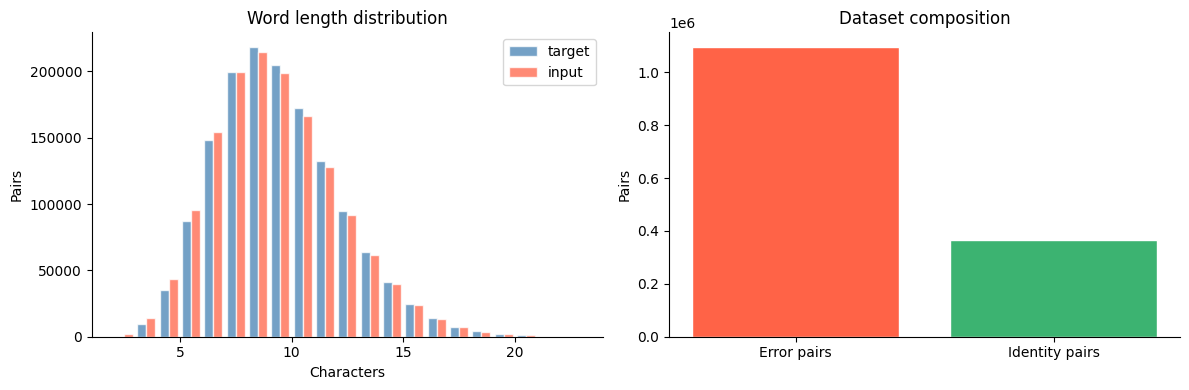

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tlen = df_full["target_text"].str.len()
ilen = df_full["input_text"].str.len()

axes[0].hist([tlen, ilen], bins=range(2, 24),
             label=["target","input"],
             color=["steelblue","tomato"], alpha=0.75, edgecolor="white")
axes[0].set_title("Word length distribution")
axes[0].set_xlabel("Characters"); axes[0].set_ylabel("Pairs"); axes[0].legend()

axes[1].bar(["Error pairs","Identity pairs"], [n_err, n_id],
            color=["tomato","mediumseagreen"], edgecolor="white")
axes[1].set_title("Dataset composition"); axes[1].set_ylabel("Pairs")

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 3 — Train / Validation Split

In [25]:
train_df, val_df = train_test_split(
    df_full, test_size=0.05, random_state=SEED, shuffle=True
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train : {len(train_df):,} pairs")
print(f"Val   : {len(val_df):,} pairs")

Train : 1,388,109 pairs
Val   : 73,059 pairs


## 4 — Data Pipeline

| Token | Index | Role |
|---|---|---|
| `<PAD>` | 0 | Pad to uniform batch length |
| `<SOS>` | 1 | Decoder start token |
| `<EOS>` | 2 | Decoder stop token |
| `<UNK>` | 3 | Unknown character fallback |

In [26]:
PAD_IDX    = char_vocab["PAD_IDX"]    # 0
SOS_IDX    = char_vocab["SOS_IDX"]    # 1
EOS_IDX    = char_vocab["EOS_IDX"]    # 2
UNK_IDX    = char_vocab["UNK_IDX"]    # 3
VOCAB_SIZE = char_vocab["vocab_size"] # 43

char2idx = char_vocab["char2idx"]
idx2char = {int(k): v for k, v in char_vocab["idx2char"].items()}


def word_to_ids(word: str) -> list[int]:
    ids = [char2idx.get(c, UNK_IDX) for c in word[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return ids


def ids_to_word(ids) -> str:
    out = []
    for i in ids:
        i = int(i)
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            out.append(idx2char.get(i, "?"))
    return "".join(out)


class SpellDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.inputs  = df["input_text"].tolist()
        self.targets = df["target_text"].tolist()

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        src_word = self.inputs[idx]
        tgt_word = self.targets[idx]

        src     = word_to_ids(src_word)
        src_len = min(len(src_word), MAX_LEN)

        payload = [char2idx.get(c, UNK_IDX) for c in tgt_word[:MAX_LEN - 1]]
        dec_in  = [SOS_IDX] + payload
        dec_tgt = payload + [EOS_IDX]
        pad_n   = MAX_LEN - len(dec_in)
        dec_in  += [PAD_IDX] * pad_n
        dec_tgt += [PAD_IDX] * pad_n

        return (
            torch.tensor(src,     dtype=torch.long),
            torch.tensor(src_len, dtype=torch.long),
            torch.tensor(dec_in,  dtype=torch.long),
            torch.tensor(dec_tgt, dtype=torch.long),
        )


train_loader = DataLoader(SpellDataset(train_df), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(SpellDataset(val_df),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")

src, src_len, dec_in, dec_tgt = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  src     {tuple(src.shape)}")
print(f"  src_len {tuple(src_len.shape)}")
print(f"  dec_in  {tuple(dec_in.shape)}")
print(f"  dec_tgt {tuple(dec_tgt.shape)}")

Train batches : 2,712
Val   batches : 143

Batch shapes:
  src     (512, 25)
  src_len (512,)
  dec_in  (512, 25)
  dec_tgt (512, 25)


## 5 — Model Definition

```
Corrupted word
     │
     ▼
Embedding  (43 → 128)
     │
     ▼
Encoder GRU  (128 → 512, 2 layers, bidirectional)
     │            outputs  (B, seq, 1024)  ← attention keys
     │            hidden   (B, 512)        ← decoder h₀
     ▼
Bahdanau Attention  (every decoder step)
     │  score = v·tanh(W_enc·enc_out + W_dec·h_dec)
     │  α = softmax(score)  [PAD positions masked]
     │  ctx = Σ α·enc_out
     ▼
Decoder GRU  (128 + 1024 → 512, 1 layer)
     │
     ▼
Linear  (512 → 43)
     │
     ▼
Corrected word
```

**Scheduled sampling** — after epoch 10, the decoder is fed its own previous
output (instead of ground-truth) with probability `ss_prob`. This forces the
model to learn to recover from its own prediction errors and prevents it from
exploiting the copy shortcut that pure teacher forcing enables.

In [27]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hid: int, dec_hid: int):
        super().__init__()
        self.W_enc = nn.Linear(enc_hid, dec_hid, bias=False)
        self.W_dec = nn.Linear(dec_hid, dec_hid, bias=False)
        self.v     = nn.Linear(dec_hid, 1,       bias=False)

    def forward(self, enc_out, dec_hid, src_mask):
        energy = torch.tanh(
            self.W_enc(enc_out) + self.W_dec(dec_hid).unsqueeze(1)
        )                                                   # (B, src_len, dec_hid)
        scores = self.v(energy).squeeze(-1)                 # (B, src_len)
        scores = scores.masked_fill(src_mask, float("-inf"))
        attn_w = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_w.unsqueeze(1), enc_out).squeeze(1)
        return context, attn_w


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru   = nn.GRU(embed_dim, hidden_dim,
                            num_layers=n_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc      = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        emb    = self.dropout(self.embed(src))
        packed = pack_padded_sequence(emb, src_lens.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, hid = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True,
                                     total_length=src.size(1))
        hid = torch.tanh(self.fc(torch.cat([hid[-2], hid[-1]], dim=1)))
        return out, hid   # (B, src_len, hid*2),  (B, hid)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hid, dec_hid, dropout):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(enc_hid, dec_hid)
        self.gru       = nn.GRU(embed_dim + enc_hid, dec_hid,
                                num_layers=1, batch_first=True)
        self.fc_out    = nn.Linear(dec_hid, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def step(self, token, hid, enc_out, src_mask):
        emb      = self.dropout(self.embed(token.unsqueeze(1)))  # (B,1,embed)
        ctx, _   = self.attention(enc_out, hid.squeeze(0), src_mask)
        gru_in   = torch.cat([emb, ctx.unsqueeze(1)], dim=2)
        out, hid = self.gru(gru_in, hid)
        logits   = self.fc_out(out.squeeze(1))                   # (B, V)
        return logits, hid


class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    @staticmethod
    def _src_mask(src):
        return src == PAD_IDX   # (B, src_len)  True=PAD

    def forward(self, src, src_lens, dec_in, ss_prob: float = 0.0):
        enc_out, hid = self.encoder(src, src_lens)
        mask = self._src_mask(src)
        hid  = hid.unsqueeze(0)                       # (1, B, dec_hid)

        logits_list = []
        token = dec_in[:, 0]                          # always SOS

        for t in range(dec_in.size(1)):
            logits, hid = self.decoder.step(token, hid, enc_out, mask)
            logits_list.append(logits.unsqueeze(1))

            if t + 1 < dec_in.size(1):
                if ss_prob > 0.0 and random.random() < ss_prob:
                    token = logits.detach().argmax(dim=-1)   # model's own pred
                else:
                    token = dec_in[:, t + 1]                 # ground truth

        return torch.cat(logits_list, dim=1)           # (B, tgt_len, V)

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len: int = MAX_LEN):
        self.eval()
        enc_out, hid = self.encoder(src, src_lens)
        mask  = self._src_mask(src)
        hid   = hid.unsqueeze(0)
        token = torch.full((src.size(0),), SOS_IDX, dtype=torch.long, device=src.device)
        preds, done = [], torch.zeros(src.size(0), dtype=torch.bool, device=src.device)

        for _ in range(max_len):
            logits, hid = self.decoder.step(token, hid, enc_out, mask)
            token = logits.argmax(dim=-1)
            preds.append(token)
            done |= (token == EOS_IDX)
            if done.all():
                break

        return torch.stack(preds, dim=1)   # (B, steps)


print("Model classes defined ✓")

Model classes defined ✓


## 6 — Instantiate Model  *(uses hyperparams from cell 0)*

In [28]:
# All values come from the hyperparameter cell — nothing hardcoded here
ENC_HID = HIDDEN_DIM * 2   # bidirectional encoder output dim = 1024

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, ENC_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, ENC_HID,   HIDDEN_DIM, DROPOUT)
model   = Seq2Seq(encoder, decoder).to(DEVICE)


def _init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.GRU, nn.LSTM)):
        for name, p in m.named_parameters():
            if "weight" in name: nn.init.orthogonal_(p)
            elif "bias"  in name: nn.init.zeros_(p)

model.apply(_init_weights)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print()
# Verify sizes match hyperparams — catches any copy-paste mistake immediately
enc_embed_dim = model.encoder.embed.embedding_dim
enc_hidden    = model.encoder.gru.hidden_size
dec_hidden    = model.decoder.gru.hidden_size
print(f"Verified embed_dim   : {enc_embed_dim}  (expected {EMBED_DIM})")
print(f"Verified enc hidden  : {enc_hidden}  (expected {HIDDEN_DIM})")
print(f"Verified dec hidden  : {dec_hidden}  (expected {HIDDEN_DIM})")
assert enc_embed_dim == EMBED_DIM, "embed_dim mismatch!"
assert enc_hidden    == HIDDEN_DIM, "hidden_dim mismatch!"
print()
print(model)

Trainable parameters : 2,815,531

Verified embed_dim   : 128  (expected 128)
Verified enc hidden  : 256  (expected 256)
Verified dec hidden  : 256  (expected 256)

Seq2Seq(
  (encoder): Encoder(
    (embed): Embedding(43, 128, padding_idx=0)
    (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (fc): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embed): Embedding(43, 128, padding_idx=0)
    (attention): BahdanauAttention(
      (W_enc): Linear(in_features=512, out_features=256, bias=False)
      (W_dec): Linear(in_features=256, out_features=256, bias=False)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (gru): GRU(640, 256, batch_first=True)
    (fc_out): Linear(in_features=256, out_features=43, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


## 7 — Training

**Scheduler:** `CosineAnnealingLR` — cosine decay from `LR` to `LR_MIN` over
`N_EPOCHS`. Simple, per-epoch, predictable. Replaced `OneCycleLR` which stuck
at a fixed value due to interaction with the `epochs` × `steps_per_epoch`
parameter in v2.

**Scheduled sampling** ramps from 0 → 25 % linearly between epochs 10–25.

In [29]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# CosineAnnealingLR: decays lr from LR to LR_MIN over N_EPOCHS
# Per-epoch step — no per-batch complexity, no parameter interaction bugs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=LR_MIN
)


def get_ss_prob(epoch: int) -> float:
    if epoch <= SS_START_EPOCH:
        return 0.0
    progress = min((epoch - SS_START_EPOCH) / SS_RAMP_EPOCHS, 1.0)
    return round(SS_MAX_PROB * progress, 4)


def exact_match_accuracy(loader, n_batches: int = 30) -> float:
    """Word-level accuracy on error pairs only (identity pairs excluded)."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for i, (src, src_len, _, dec_tgt) in enumerate(loader):
            if i >= n_batches:
                break
            src = src.to(DEVICE); src_len = src_len.to(DEVICE)
            preds = model.greedy_decode(src, src_len)
            for j in range(src.size(0)):
                pred_w = ids_to_word(preds[j].tolist())
                true_w = ids_to_word(dec_tgt[j].tolist())
                src_w  = ids_to_word(src[j].tolist())
                if src_w != true_w:          # only score error pairs
                    total   += 1
                    correct += int(pred_w == true_w)
    return correct / total if total > 0 else 0.0


# ── Training ───────────────────────────────────────────────────────────────
train_losses, val_losses, val_accs = [], [], []
best_val   = float("inf")
no_improve = 0

header = (f"{'Epoch':>6}  {'Train':>9}  {'Val':>9}  "
          f"{'Val PPL':>8}  {'Val Acc%':>9}  {'SS prob':>8}  {'LR':>9}  {'Time':>6}")
print(header)
print("─" * len(header))

for epoch in range(1, N_EPOCHS + 1):
    t0      = time.time()
    ss_prob = get_ss_prob(epoch)

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    train_loss_sum = 0.0
    for src, src_len, dec_in, dec_tgt in train_loader:
        src, src_len    = src.to(DEVICE), src_len.to(DEVICE)
        dec_in, dec_tgt = dec_in.to(DEVICE), dec_tgt.to(DEVICE)

        logits = model(src, src_len, dec_in, ss_prob=ss_prob)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), dec_tgt.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for src, src_len, dec_in, dec_tgt in val_loader:
            src, src_len    = src.to(DEVICE), src_len.to(DEVICE)
            dec_in, dec_tgt = dec_in.to(DEVICE), dec_tgt.to(DEVICE)
            logits = model(src, src_len, dec_in, ss_prob=0.0)
            val_loss_sum += criterion(
                logits.reshape(-1, VOCAB_SIZE), dec_tgt.reshape(-1)
            ).item()

    val_loss = val_loss_sum / len(val_loader)
    val_acc  = exact_match_accuracy(val_loader, n_batches=30)

    # Scheduler steps per epoch (not per batch)
    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    improved = val_loss < best_val
    if improved:
        best_val   = val_loss
        no_improve = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "val_loss"   : val_loss,
            "val_acc"    : val_acc,
            "char_vocab" : char_vocab,
            "hparams": {
                "embed_dim" : EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "enc_layers": ENC_LAYERS,
                "dropout"   : DROPOUT,
                "vocab_size": VOCAB_SIZE,
                "max_len"   : MAX_LEN,
            },
        }, SAVE_PATH)
    else:
        no_improve += 1

    flag = " ✓" if improved else ""
    print(f"{epoch:>6}  {train_loss:>9.4f}  {val_loss:>9.4f}  "
          f"{math.exp(val_loss):>8.3f}  {val_acc*100:>9.2f}  "
          f"{ss_prob:>8.4f}  {cur_lr:>9.2e}  {time.time()-t0:>5.0f}s{flag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest — val loss {best_val:.4f}  PPL {math.exp(best_val):.3f}")
print(f"Saved : {SAVE_PATH}")

 Epoch      Train        Val   Val PPL   Val Acc%   SS prob         LR    Time
──────────────────────────────────────────────────────────────────────────────
     1     0.4078     0.2706     1.311      26.04    0.0000   3.00e-04    421s ✓
     2     0.2661     0.2395     1.271      32.36    0.0000   2.98e-04    420s ✓
     3     0.2384     0.2223     1.249      35.95    0.0000   2.96e-04    420s ✓
     4     0.2216     0.2087     1.232      38.72    0.0000   2.93e-04    420s ✓
     5     0.2106     0.2079     1.231      41.21    0.0000   2.89e-04    420s ✓
     6     0.2013     0.1963     1.217      41.91    0.0000   2.84e-04    420s ✓
     7     0.1937     0.1914     1.211      44.12    0.0000   2.79e-04    420s ✓
     8     0.1878     0.1845     1.203      44.84    0.0000   2.72e-04    420s ✓
     9     0.1821     0.1833     1.201      45.88    0.0000   2.65e-04    421s ✓
    10     0.1778     0.1772     1.194      46.68    0.0000   2.58e-04    421s ✓
    11     0.1771     0.1756    

## 8 — Loss & Accuracy Curves

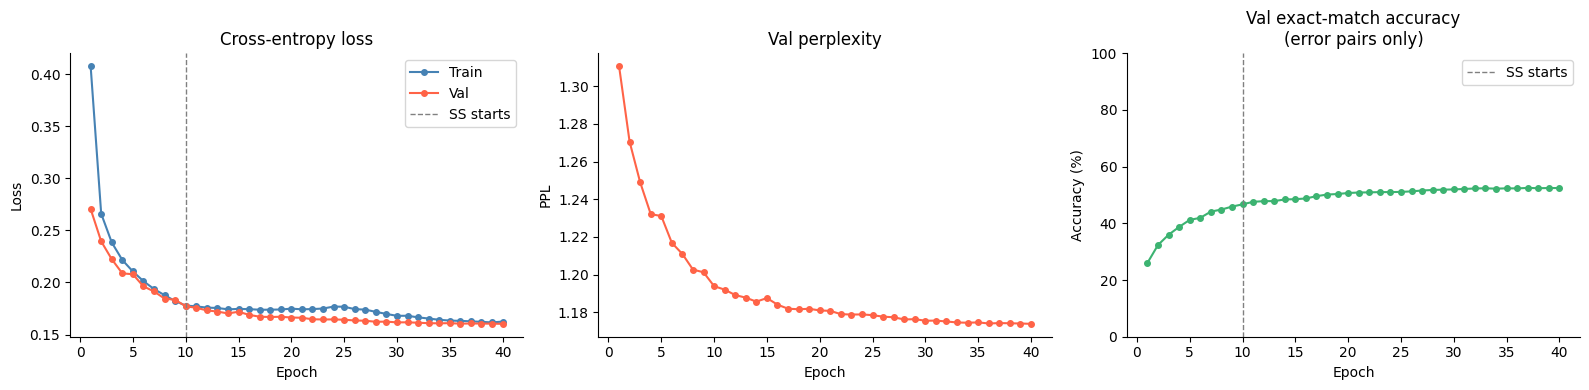

Best val loss — 0.1603  (PPL 1.174)
Best val acc  — 52.5%


In [30]:
n  = len(train_losses)
xs = range(1, n + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(xs, train_losses, "o-", color="steelblue", ms=4, label="Train")
axes[0].plot(xs, val_losses,   "o-", color="tomato",    ms=4, label="Val")
axes[0].axvline(x=SS_START_EPOCH, color="grey", ls="--", lw=1, label="SS starts")
axes[0].set_title("Cross-entropy loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(xs, [math.exp(l) for l in val_losses], "o-", color="tomato", ms=4)
axes[1].set_title("Val perplexity"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PPL")

axes[2].plot(xs, [a * 100 for a in val_accs], "o-", color="mediumseagreen", ms=4)
axes[2].axvline(x=SS_START_EPOCH, color="grey", ls="--", lw=1, label="SS starts")
axes[2].set_title("Val exact-match accuracy\n(error pairs only)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy (%)"); axes[2].set_ylim(0, 100)
axes[2].legend()

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120)
plt.show()

print(f"Best val loss — {best_val:.4f}  (PPL {math.exp(best_val):.3f})")
print(f"Best val acc  — {max(val_accs)*100:.1f}%")

## 9 — Inference Verification  *(best checkpoint)*

In [31]:
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Checkpoint  : epoch {ckpt['epoch']}, "
      f"val loss {ckpt['val_loss']:.4f}, "
      f"val acc {ckpt.get('val_acc', 0)*100:.1f}%")
print(f"Hparams     : {ckpt['hparams']}")


def correct_word(word: str) -> str:
    src     = torch.tensor([word_to_ids(word)], dtype=torch.long, device=DEVICE)
    src_len = torch.tensor([min(len(word), MAX_LEN)], dtype=torch.long)
    preds   = model.greedy_decode(src, src_len)
    return ids_to_word(preds[0].tolist())


test_cases = [
    # already correct
    ("გამარჯობა",    "გამარჯობა"),
    ("თბილისი",      "თბილისი"),
    ("საქართველო",   "საქართველო"),
    ("ქართული",      "ქართული"),
    ("კომპიუტერი",   "კომპიუტერი"),
    ("სკოლა",        "სკოლა"),
    ("მასწავლებელი", "მასწავლებელი"),
    ("ენა",          "ენა"),
    ("წიგნი",        "წიგნი"),
    ("სახელი",       "სახელი"),
    # omission
    ("პროგამა",      "პროგრამა"),
    ("კომპიუტრი",    "კომპიუტერი"),
    ("გამრჯობა",     "გამარჯობა"),
    ("საქრთველო",    "საქართველო"),
    ("მსწავლებელი",  "მასწავლებელი"),
    # keyboard swap
    ("გამარჰობა",    "გამარჯობა"),
    ("სახეიბ",       "სახელი"),
    ("წიბნი",        "წიგნი"),
    # transposition
    ("ბთილისი",      "თბილისი"),
    ("სქოლა",        "სკოლა"),
    # phonetic confusion
    ("ქარგი",        "კარგი"),
    ("ქომპიუტერი",   "კომპიუტერი"),
    # insertion
    ("სკოლაა",       "სკოლა"),
    ("ენაი",         "ენა"),
    ("წიგნიი",       "წიგნი"),
]

ok = 0
print(f"{'INPUT':<24} {'PREDICTED':<24} {'EXPECTED':<24} PASS?")
print("─" * 90)
for inp, exp in test_cases:
    pred  = correct_word(inp)
    match = pred == exp
    ok   += int(match)
    print(f"{inp:<24} {pred:<24} {exp:<24} {'✓' if match else '✗'}")

print()
print(f"Accuracy : {ok}/{len(test_cases)}  ({ok/len(test_cases)*100:.0f}%)")
id_ok  = sum(1 for inp, exp in test_cases if inp == exp and correct_word(inp) == exp)
err_ok = sum(1 for inp, exp in test_cases if inp != exp and correct_word(inp) == exp)
n_err_cases = sum(1 for inp, exp in test_cases if inp != exp)
print(f"  Identity    : {id_ok}/10")
print(f"  Corrections : {err_ok}/{n_err_cases}")

Checkpoint  : epoch 40, val loss 0.1603, val acc 52.4%
Hparams     : {'embed_dim': 128, 'hidden_dim': 256, 'enc_layers': 2, 'dropout': 0.3, 'vocab_size': 43, 'max_len': 25}
INPUT                    PREDICTED                EXPECTED                 PASS?
──────────────────────────────────────────────────────────────────────────────────────────
გამარჯობა                გამარჯობა                გამარჯობა                ✓
თბილისი                  თბილისი                  თბილისი                  ✓
საქართველო               საქართველო               საქართველო               ✓
ქართული                  ქართული                  ქართული                  ✓
კომპიუტერი               კომპიუტერი               კომპიუტერი               ✓
სკოლა                    სკოლა                    სკოლა                    ✓
მასწავლებელი             მასწავლებელი             მასწავლებელი             ✓
ენა                      ენა                      ენა                      ✓
წიგნი                    წიგნი         

## 10 — Save Model

In [32]:
print(f"Path : {SAVE_PATH.resolve()}")
print(f"Size : {SAVE_PATH.stat().st_size / 1e6:.1f} MB")
print()
for k, v in torch.load(SAVE_PATH, map_location="cpu").items():
    if k == "model_state":
        print(f"  model_state  — {len(v)} tensors")
    elif k == "char_vocab":
        print(f"  char_vocab   — vocab_size={v['vocab_size']}")
    elif k == "hparams":
        print(f"  hparams      — {v}")
    else:
        print(f"  {k:<12} — {v}")

Path : /kaggle/working/georgian_spellcheck_model.pt
Size : 11.3 MB

  epoch        — 40
  model_state  — 29 tensors
  val_loss     — 0.16028832243039057
  val_acc      — 0.5242968951578223
  char_vocab   — vocab_size=43
  hparams      — {'embed_dim': 128, 'hidden_dim': 256, 'enc_layers': 2, 'dropout': 0.3, 'vocab_size': 43, 'max_len': 25}
